In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
import kagglehub
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, Input, BatchNormalization
)
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
from tensorflow.keras.applications import VGG16

warnings.filterwarnings("ignore")


In [ ]:
'''Training adathalmaz betöltése'''
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

train_dir = os.path.join(path, 'Training')
print(train_dir)

/kaggle/input/brain-tumor-mri-dataset/Training


In [ ]:
'''Teszt adathalmaz betöltése'''
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

test_dir = os.path.join(path, 'Testing')
print(test_dir)

/kaggle/input/brain-tumor-mri-dataset/Testing


In [ ]:
'''Other címkés adathalmaz betöltése'''
path = kagglehub.dataset_download("prasunroy/natural-images")

other_dir = os.path.join(path, 'natural_images')
print(other_dir)

/kaggle/input/natural-images/natural_images


In [ ]:
'''Other címkés adatok képeinek és címkéinek begyűjtése'''
image_paths = []
image_labels = []

categories = os.listdir(other_dir)

for category in categories:
    category_path = os.path.join(other_dir, category)
    images = os.listdir(category_path)

    for image in images:
        image_path = os.path.join(category_path, image)
        image_paths.append(image_path)
        image_labels.append("other")

other_df = pd.DataFrame(data={'filepaths': image_paths, 'labels': image_labels})
other_df

,filepaths,labels
0,/kaggle/input/natural-images/natural_images/mo...,other
1,/kaggle/input/natural-images/natural_images/mo...,other
2,/kaggle/input/natural-images/natural_images/mo...,other
3,/kaggle/input/natural-images/natural_images/mo...,other
4,/kaggle/input/natural-images/natural_images/mo...,other
...,...,...
6894,/kaggle/input/natural-images/natural_images/pe...,other
6895,/kaggle/input/natural-images/natural_images/pe...,other
6896,/kaggle/input/natural-images/natural_images/pe...,other
6897,/kaggle/input/natural-images/natural_images/pe...,other


In [ ]:
'''Tumor címkés adatok training képeinek és címkéinek begyűjtése'''
image_paths = []
image_labels = []

categories = os.listdir(train_dir)

for category in categories:
    category_path = os.path.join(train_dir, category)
    images = os.listdir(category_path)

    for image in images:
        image_path = os.path.join(category_path, image)
        image_paths.append(image_path)
        image_labels.append(category)

train_df = pd.DataFrame(data={'filepaths': image_paths, 'labels': image_labels})
train_df

,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [ ]:
'''Tumor címkés adatok teszt képeinek és címkéinek begyűjtése'''
image_paths = []
image_labels = []

categories = os.listdir(test_dir)

for category in categories:
    category_path = os.path.join(test_dir, category)
    images = os.listdir(category_path)

    for image in images:
        image_path = os.path.join(category_path, image)
        image_paths.append(image_path)
        image_labels.append(category)

test_df = pd.DataFrame(data={'filepaths': image_paths, 'labels': image_labels})
test_df

,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1306,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1307,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1308,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1309,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


In [ ]:
'''Tumor és other adathalmazok konkatenálása és keverése'''
other_train_df = other_df.sample(n=1500, random_state=42)
other_test_df = other_df.drop(other_train_df.index).sample(n=300, random_state=42)

train_df = pd.concat([train_df, other_train_df], ignore_index=True)
test_df = pd.concat([test_df, other_test_df], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Training set: {train_df.shape}, Testing set: {test_df.shape}")


Training set: (7212, 2), Testing set: (1611, 2)


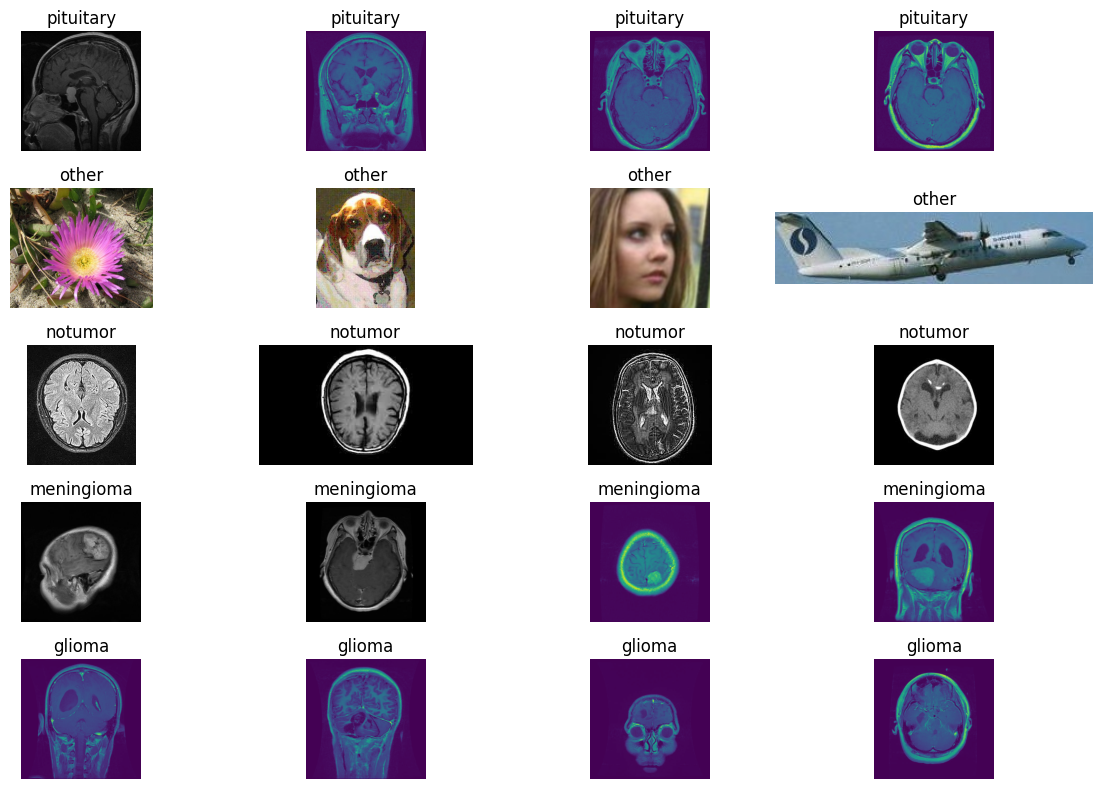

In [ ]:
'''Példa képek kirajzolása'''
def plot_class_samples(df, classes, num_samples=4):
    plt.figure(figsize=(12,8))

    for i, cls in enumerate(classes):
        class_images = df[df['labels'] == cls]['filepaths'].sample(num_samples, random_state=42)

        for j, img_path in enumerate(class_images):
            img = Image.open(img_path)  # Load the image
            plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(cls)

    plt.tight_layout()
    plt.show()
classes = train_df['labels'].unique()

plot_class_samples(train_df, classes)

In [ ]:
'''Címkék sorrendjének meghatározása'''
true_labels = sorted(test_df['labels'].unique())
print(true_labels)

['glioma', 'meningioma', 'notumor', 'other', 'pituitary']


Text(0.5, 1.0, 'Train labels count')

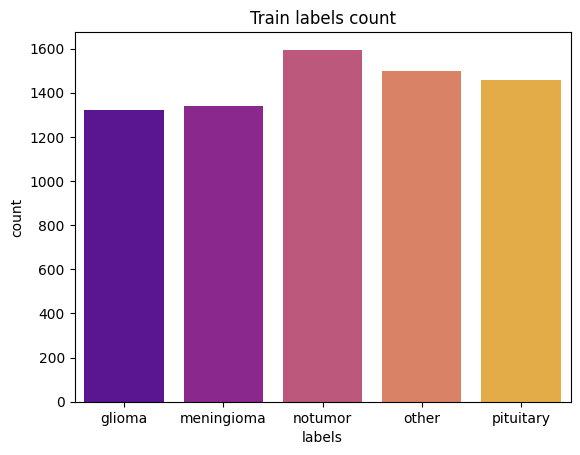

In [ ]:
'''Training adatok mennyisége'''
sns.countplot(data=train_df,x='labels',palette='plasma',order=true_labels)
plt.title('Train labels count')

Text(0.5, 1.0, 'Test labels count')

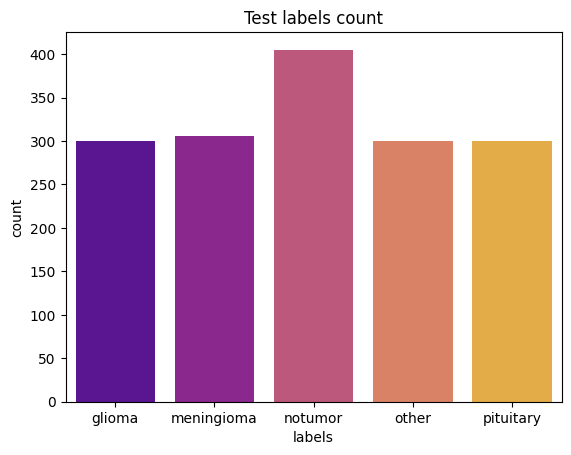

In [ ]:
'''Teszt adatok mennyisége'''
sns.countplot(data=test_df,x='labels',palette='plasma',order=true_labels)
plt.title('Test labels count')

In [ ]:
'''Training és validációs halmaz elválasztása'''
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [ ]:
'''Generátorok előállítása'''
def prepare_the_datasets(train_df, valid_df, test_df, batch_size, image_size):

    train_datasets_generator = ImageDataGenerator(rescale=1.0/255, brightness_range=(0.8, 1.2))

    validation_datasets_generator = ImageDataGenerator(rescale=1.0/255)
    test_datasets_generator = ImageDataGenerator(rescale=1.0/255)

    train_datasets_generator_data = train_datasets_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepaths',
        y_col='labels',
        batch_size=batch_size,
        shuffle=True,
        target_size=(image_size, image_size),
        class_mode="categorical"
    )

    validation_datasets_generator_data = validation_datasets_generator.flow_from_dataframe(
        dataframe=valid_df,
        x_col='filepaths',
        y_col='labels',
        batch_size=batch_size,
        shuffle=True,
        target_size=(image_size, image_size),
        class_mode="categorical"
    )

    test_datasets_generator_data = test_datasets_generator.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepaths',
        y_col='labels',
        batch_size=batch_size,
        shuffle=False,
        target_size=(image_size, image_size),
        class_mode="categorical"
    )
    return train_datasets_generator_data, validation_datasets_generator_data, test_datasets_generator_data


In [ ]:
batch_size = 64
image_size = 224
train_data , validation_data, test_data = prepare_the_datasets(train_df, valid_df, test_df, batch_size, image_size)

Found 5769 validated image filenames belonging to 5 classes.
Found 1443 validated image filenames belonging to 5 classes.
Found 1611 validated image filenames belonging to 5 classes.


In [ ]:
'''Model meghatározása'''
base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(5, activation='softmax')(x)

model1 = Model(inputs, outputs)


model1.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


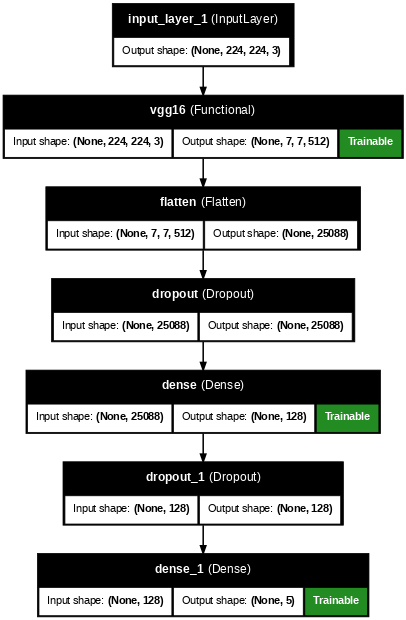

In [ ]:
plot_model(
    model1,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=55,
    show_layer_activations=False,
    show_trainable=True
)

In [ ]:
'''Model tanítása'''
steps = int(train_data.samples / batch_size)
epochs = 10

history = model1.fit(train_data, validation_data = validation_data ,
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5143s 57s/step - accuracy: 0.6806 - loss: 0.8176 - val_accuracy: 0.9321 - val_loss: 0.1785
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 922s 10s/step - accuracy: 0.9375 - loss: 0.1891 - val_accuracy: 0.9161 - val_loss: 0.2146
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5159s 57s/step - accuracy: 0.9331 - loss: 0.1982 - val_accuracy: 0.9425 - val_loss: 0.1582
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 937s 10s/step - accuracy: 0.8906 - loss: 0.2818 - val_accuracy: 0.9584 - val_loss: 0.1082
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5149s 57s/step - accuracy: 0.9478 - loss: 0.1339 - val_accuracy: 0.9605 - val_loss: 0.1002
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 970s 10s/step - accuracy: 1.0000 - loss: 0.0428 - val_accuracy: 0.9591 - val_loss: 0.1035
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5086s 56s/step - accuracy: 0.9696 - loss: 0.0872 - val_accuracy: 0.9709 - val_loss: 0.0831
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 922s 10s/step - accuracy: 0.9844 - loss: 0.0563 - val_accuracy

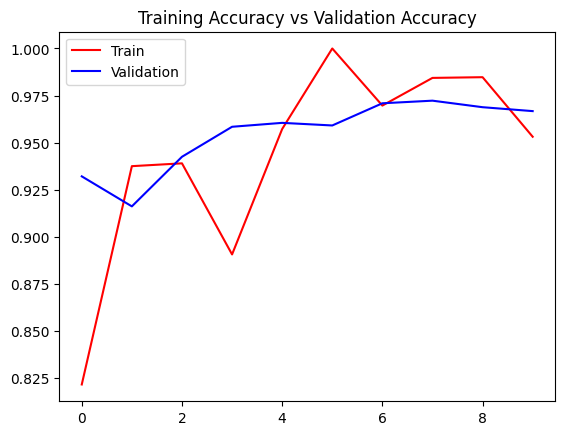

In [ ]:
'''Model pontosságának kirajzolása'''
plt.title('Training Accuracy vs Validation Accuracy')

plt.plot(history.history['accuracy'], color='red',label='Train')
plt.plot(history.history['val_accuracy'], color='blue',label='Validation')

plt.legend()

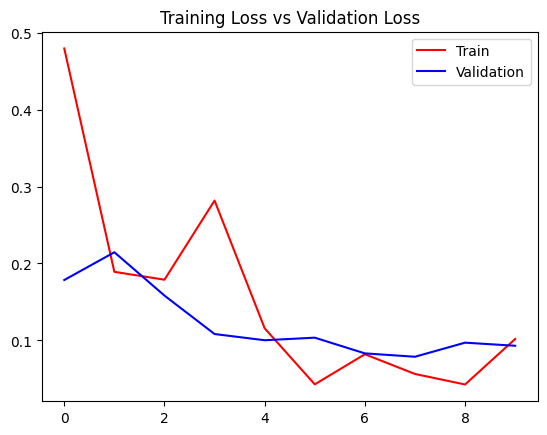

In [ ]:
'''Model Költségének kirajzolása'''
plt.title('Training Loss vs Validation Loss')

plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Validation')

plt.legend()

In [ ]:
'''Predikciós statisztikák'''
pred=model1.predict(test_data)
predictions=np.argmax(pred,axis=1)
print(classification_report(test_data.classes,predictions))

26/26 ━━━━━━━━━━━━━━━━━━━━ 979s 38s/step
              precision    recall  f1-score   support

           0       1.00      0.83      0.91       300
           1       0.82      0.98      0.89       306
           2       1.00      1.00      1.00       405
           3       1.00      1.00      1.00       300
           4       0.99      0.94      0.96       300

    accuracy                           0.95      1611
   macro avg       0.96      0.95      0.95      1611
weighted avg       0.96      0.95      0.95      1611



In [ ]:
'''Model kiértékelése'''
model1.evaluate(test_data)

26/26 ━━━━━━━━━━━━━━━━━━━━ 977s 37s/step - accuracy: 0.9527 - loss: 0.1333


[0.1334720253944397, 0.9540657997131348]

<Axes: >

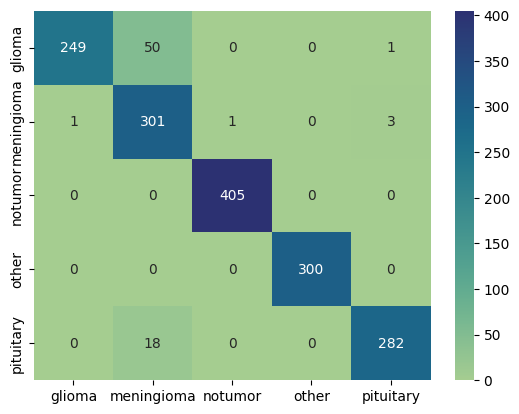

In [ ]:
'''Konfúziós mátrix kirajzolása'''
conf_matrix = confusion_matrix(test_data.classes, predictions)
labels = list(train_df['labels'].unique())
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='crest', xticklabels=true_labels, yticklabels=true_labels)

In [ ]:
'''Model mentése'''
model1.save("tumor.h5")

In [ ]:
'''Model letöltése'''
from google.colab import files
files.download("tumor2.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step


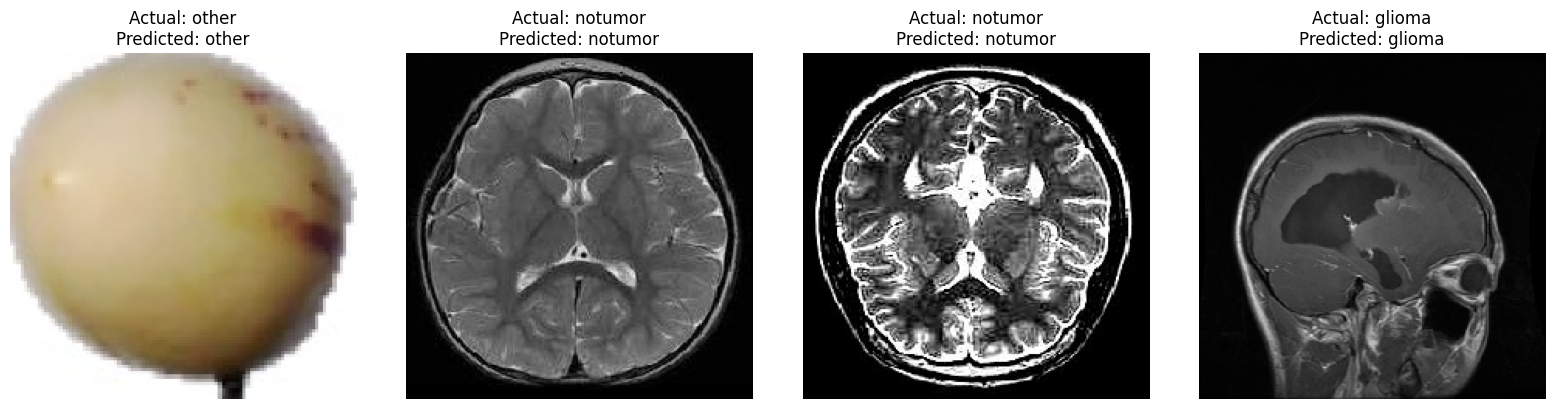

In [ ]:
'''Random képeken való kiértékelés'''
import random
random_indices = random.sample(range(len(test_df)), 4)
random_paths = test_df.iloc[random_indices]['filepaths'].values
actual_labels = test_df.iloc[random_indices]['labels'].values

plt.figure(figsize=(16, 4))

for i, img_path in enumerate(random_paths):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    pred = model1.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]
    class_labels = list(train_data.class_indices.keys())
    predicted_label = class_labels[predicted_class]

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Actual: {actual_labels[i]}\nPredicted: {predicted_label}')

plt.tight_layout()
plt.show()